# Pythia: Momentum Investing — Strategy Builder & Backtester

This notebook builds a full quantitative momentum investing pipeline on the S&P 500
universe.



# Notebook Structure

| Section | Topic |
|---------|-------|
| **1** | Imports & Global Configuration |
| **2** | Incremental Data Update |
| **3** | Data Quality & Cleaning |
| **4** | Exploratory Data Analysis |
| **5** | Momentum Signal Definitions |
| **6** | Walk-Forward Backtesting Engine |
| **7** | Machine Learning Layer |
| **8** | Performance Metrics & Visualisation |
| **9** | Fama-French 3-Factor Risk Adjustment |
| **10** | Current Stock Screener |



> **Data source:** 10-year daily OHLCV prices for S&P 500 constituents stored in
> `sp500_prices.duckdb` (table: `daily_prices`). Built with `download_sp500_to_duckdb.py`
> and kept current by Section 2 of this notebook.

---
## 1. Imports & Global Configuration

All imports in a single cell so dependencies are explicit and easy to audit.
All numeric constants are defined here — never buried inside functions — so
changing any assumption (cost, lookback, threshold) requires editing one place only.

| Library | Purpose |
|---------|---------|
| `duckdb` | Analytical SQL engine — reads the local price database |
| `numpy` | Fast numerical arrays and mathematical operations |
| `pandas` | DataFrames, time-series resampling, method-chaining |
| `yfinance` | Fetches missing price history from Yahoo Finance |
| `matplotlib / seaborn` | Static charts and dashboards |
| `scipy.stats` | Normal distribution — used in signal z-scoring |
| `sklearn` | Logistic Regression, Random Forest, walk-forward split |
| `lightgbm` | Gradient boosting classifier — strongest ML baseline |
| `requests` | Fetches Fama-French factor CSV from Kenneth French's website |

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import time
import warnings
import requests
import zipfile
import io
from datetime import date, timedelta
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Data & numerics ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import duckdb
import yfinance as yf

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Statistics & machine learning ─────────────────────────────────────────────
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# ── Seaborn global theme ──────────────────────────────────────────────────────
# 'whitegrid' gives clean axes; font_scale=1.1 makes text readable in notebooks
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)

# ── Display options ───────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

# ── Paths ─────────────────────────────────────────────────────────────────────
DB_PATH = Path("sp500_prices.duckdb")

# ── Finance constants ─────────────────────────────────────────────────────────
TRADING_DAYS         = 252            # exchange-open days per calendar year
RF_ANNUAL            = 0.04           # annual risk-free rate (4 %)
BACKTEST_START       = "2015-01-01"   # backtest window start date

# ── Backtest parameters ───────────────────────────────────────────────────────
TRANSACTION_COST_BPS = 10             # flat cost per side in basis points (1 bp = 0.01 %)
TOP_DECILE           = 0.10           # top 10 % of ranked stocks → long portfolio
BOTTOM_DECILE        = 0.10           # bottom 10 % of ranked stocks → short portfolio
REBALANCE_FREQ       = "ME"           # pandas month-end offset alias

# ── Data quality thresholds ───────────────────────────────────────────────────
MIN_HISTORY_YEARS    = 8              # tickers with fewer years of data are excluded
MAX_CONSEC_MISSING   = 5              # flag tickers with gaps longer than 5 trading days
MAX_DAILY_RETURN     = 0.40           # flag single-day moves above 40 % (likely data errors)

# ── Colour palette ────────────────────────────────────────────────────────────
# Defined as a dict so the mapping is always explicit, never index-dependent
COLOURS = {
    "MOM_12_1"  : "#2196F3",   # blue
    "MOM_3_1"   : "#4CAF50",   # green
    "MA_Cross"  : "#FF9800",   # orange
    "RSI_14"    : "#9C27B0",   # purple
    "Composite" : "#F44336",   # red
    "ML"        : "#00BCD4",   # cyan
    "Benchmark" : "#9E9E9E",   # grey
}

SIGNAL_COLS = ["MOM_12_1", "MOM_3_1", "MA_Cross", "RSI_14"]   # raw signals (no Composite)

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 2. Incremental Data Update

### Why incremental?

The original `download_sp500_to_duckdb.py` script built the database by pulling
10 years of history for ~500 tickers — a process requiring anti-blocking safeguards
and 10–15 minutes to run. Each time **this notebook** is run, we only need to fetch
the days that are missing since the last download — typically a handful of trading
days. This is fast (seconds) and quiet enough that no rate-limiting safeguards are needed.

### Logic

For each ticker already in `daily_prices`:

1. Query `MAX(date)` — the last date stored for that ticker
2. If `MAX(date) < yesterday`, download only the missing window from yfinance
3. Append new rows using `INSERT OR IGNORE` — safe to re-run, no duplicates
4. A 0.3-second pause between tickers is sufficient at this request volume

The ticker list comes directly from DuckDB — no external lookup required.

In [3]:
# ── Helper: get the last stored date per ticker ───────────────────────────────
def get_last_dates(con):
    """
    Returns a DataFrame [ticker, last_date] — the most recent row in
    daily_prices for every ticker.  Used to determine which tickers are stale.
    """
    return con.execute("""
        SELECT ticker, MAX(date) AS last_date
        FROM   daily_prices
        GROUP  BY ticker
        ORDER  BY ticker
    """).df()


# ── Helper: fetch missing days from yfinance for one ticker ───────────────────
def fetch_missing(ticker, from_date, to_date):
    """
    Downloads OHLCV for [from_date, to_date] for a single ticker.
    Returns a tidy DataFrame ready for INSERT, or None if yfinance
    returned an empty result (delisted / no trading days in window).

    auto_adjust=True gives split- and dividend-adjusted prices — matching
    the schema the database was built with.
    """
    raw = yf.download(
        tickers=ticker,
        start=from_date.strftime("%Y-%m-%d"),
        end=(to_date + timedelta(days=1)).strftime("%Y-%m-%d"),  # yfinance end is exclusive
        auto_adjust=True,
        progress=False,
        threads=False,
    )

    if raw is None or raw.empty:
        return None

    # yfinance returns MultiIndex columns even for a single ticker — flatten them
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = raw.reset_index()
    df.columns = [c.lower().strip() for c in df.columns]

    # Normalise the date column name (varies slightly across yfinance versions)
    date_col = [c for c in df.columns if "date" in c or "datetime" in c][0]
    df = df.rename(columns={date_col: "date"})

    # Keep only the columns that exist in daily_prices schema
    keep = [c for c in ["date", "open", "high", "low", "close", "volume"] if c in df.columns]
    df   = df[keep].copy()

    # ── Type coercion — matches the original database schema exactly ──────────
    # Price columns: coerce to float; volume: coerce to nullable integer.
    # .apply(pd.to_numeric) replaces the column-by-column loop — same result,
    # one vectorised operation across all price columns simultaneously.
    df["date"]    = pd.to_datetime(df["date"]).dt.date
    df["ticker"]  = ticker

    price_cols    = [c for c in ["open", "high", "low", "close"] if c in df.columns]
    df[price_cols] = df[price_cols].apply(pd.to_numeric, errors="coerce")

    if "volume" in df.columns:
        df["volume"] = pd.to_numeric(df["volume"], errors="coerce").astype("Int64")

    df = df.dropna(subset=["close"])
    return df if not df.empty else None


# ── Helper: insert new rows safely ────────────────────────────────────────────
def insert_rows(con, df):
    """
    Inserts df into daily_prices using INSERT OR IGNORE.
    The PRIMARY KEY on (date, ticker) prevents duplicates, so this
    function is safe to call multiple times on the same data.
    """
    if df is None or df.empty:
        return 0
    con.register("_tmp", df)
    con.execute("""
        INSERT OR IGNORE INTO daily_prices
        SELECT date, ticker, open, high, low, close, volume
        FROM   _tmp
    """)
    con.unregister("_tmp")
    return len(df)


print("✓ Update helper functions defined.")

✓ Update helper functions defined.


In [5]:

# RUN INCREMENTAL UPDATE

TODAY = date.today()
YEST  = TODAY - timedelta(days=1)
BATCH_SIZE = 50     # tickers per yfinance call — balances speed and reliability

con           = duckdb.connect(str(DB_PATH))
last_dates_df = get_last_dates(con)

# Identify stale tickers (last_date < yesterday)
stale = (
    last_dates_df
    .assign(last_date=lambda x: pd.to_datetime(x["last_date"]).dt.date)
    .query("last_date < @YEST")
    .reset_index(drop=True)
)

print(f"Tickers in database : {len(last_dates_df):>5}")
print(f"Tickers to update   : {len(stale):>5}  |  fetching up to {YEST}\n")

# Batch download 
# Group stale tickers into batches of BATCH_SIZE.  For each batch we fetch
# from the earliest missing date across all tickers in that batch — a few
# extra rows may be downloaded for tickers that are less stale, but
# INSERT OR IGNORE silently discards any rows already in the database.
total_rows = 0
failed     = []

batches = [
    stale.iloc[i : i + BATCH_SIZE]
    for i in range(0, len(stale), BATCH_SIZE)
]

for batch in batches:
    ticker_list = batch["ticker"].tolist()
    fetch_from  = batch["last_date"].min() + timedelta(days=1)  # earliest missing date

    if fetch_from > YEST:
        continue

    raw = yf.download(
        tickers=ticker_list,
        start=fetch_from.strftime("%Y-%m-%d"),
        end=(YEST + timedelta(days=1)).strftime("%Y-%m-%d"),   # yfinance end is exclusive
        auto_adjust=True,
        progress=False,
        threads=True,    # parallel within the batch — safe at this size
    )

    if raw is None or raw.empty:
        failed.extend(ticker_list)
        continue

    # Reshape wide MultiIndex output → long format 
    # yfinance returns (field, ticker) MultiIndex columns for multi-ticker calls.
    # Stack the ticker level to get one row per (date, ticker) observation.
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns.names = ["field", "ticker"]
        try:
            long_df = raw.stack(level="ticker", future_stack=True).reset_index()
        except TypeError:
            long_df = raw.stack(level="ticker").reset_index()
    else:
        # Single ticker returned as flat DataFrame
        long_df = raw.reset_index()
        long_df["ticker"] = ticker_list[0]

    # Normalise columns
    long_df.columns = [c.lower().strip() for c in long_df.columns]

    date_col = [c for c in long_df.columns if "date" in c or "datetime" in c][0]
    long_df  = long_df.rename(columns={date_col: "date"})

    long_df["date"]   = pd.to_datetime(long_df["date"]).dt.date
    long_df["ticker"] = long_df["ticker"].astype(str)

    price_cols        = [c for c in ["open", "high", "low", "close"] if c in long_df.columns]
    long_df[price_cols] = long_df[price_cols].apply(pd.to_numeric, errors="coerce")

    if "volume" in long_df.columns:
        long_df["volume"] = pd.to_numeric(long_df["volume"], errors="coerce").astype("Int64")

    long_df = long_df.dropna(subset=["close"])

    if not long_df.empty:
        total_rows += insert_rows(con, long_df)

# Final DB stats
db_stats = con.execute("""
    SELECT MIN(date) AS earliest,
           MAX(date) AS latest,
           COUNT(DISTINCT ticker) AS n_tickers
    FROM   daily_prices
""").df()

con.close()

# Summary
print(f"Batches processed   : {len(batches):>5}")
print(f"New rows inserted   : {total_rows:>5,}")
print(f"No data returned    : {len(failed):>5}  tickers")
print(f"DB date range       : {db_stats['earliest'].iloc[0]}  →  {db_stats['latest'].iloc[0]}")
print(f"Total tickers in DB : {db_stats['n_tickers'].iloc[0]:>5}")

if failed:
    print(f"\n⚠  No data returned for : {', '.join(failed)}")

Tickers in database :   503
Tickers to update   :   503  |  fetching up to 2026-03-22

Batches processed   :    11
New rows inserted   :   503
No data returned    :     0  tickers
DB date range       : 2016-03-21 00:00:00  →  2026-03-20 00:00:00
Total tickers in DB :   503


---
## 3. Data Quality & Cleaning

Before building signals or running a backtest we need to verify that the raw
data is fit for purpose. Three checks are applied — each one addresses a
distinct failure mode:

| Check | Threshold | Why it matters |
|-------|-----------|----------------|
| **Insufficient history** | < 8 years of trading days | Momentum signals need at least 12 months of history; 8 years ensures we can also run the full 2015–present backtest |
| **Large consecutive gaps** | > 5 missing trading days | Gaps longer than a working week suggest a data feed problem, not just a public holiday |
| **Abnormal single-day returns** | \|return\| > 40 % | Moves this large are almost always split or dividend data errors rather than real price moves |

Tickers that fail any check are removed from the **clean universe** and recorded
in `flagged_df` with the reason, so we have a full audit trail.

In [6]:
# LOAD FULL PRICE TABLE FROM DUCKDB
con = duckdb.connect(str(DB_PATH))

prices_raw = (
    con.execute("""
        SELECT date, ticker, close
        FROM   daily_prices
        ORDER  BY ticker, date
    """)
    .df()
    .assign(date=lambda x: pd.to_datetime(x["date"]))
)

con.close()

print(f"Raw table shape : {prices_raw.shape}")
print(f"Tickers         : {prices_raw['ticker'].nunique()}")
print(f"Date range      : {prices_raw['date'].min().date()}  →  {prices_raw['date'].max().date()}")

Raw table shape : (1230611, 3)
Tickers         : 503
Date range      : 2016-03-21  →  2026-03-20


In [11]:
# QUALITY CHECKS
# Three checks applied to the raw price table before any analysis.
# Tickers failing any check are removed from the clean universe.
MIN_TRADING_DAYS = int(MIN_HISTORY_YEARS * TRADING_DAYS)

# Compute gaps and log-returns in one chain — both checks need them
prices_sorted = (
    prices_raw
    .sort_values(["ticker", "date"])
    .assign(
        gap     = lambda x: x.groupby("ticker")["date"].diff().dt.days,
        log_ret = lambda x: x.groupby("ticker")["close"]
                             .transform(lambda p: np.log(p / p.shift(1)))
    )
)

# Check 1: Insufficient history — fewer than MIN_TRADING_DAYS rows
ticker_counts = prices_raw.groupby("ticker")["date"].count()
short_history = ticker_counts[ticker_counts < MIN_TRADING_DAYS].index

# Check 2: Large consecutive gaps — any gap exceeding 7 calendar days
max_gap    = prices_sorted.groupby("ticker")["gap"].max()
large_gaps = max_gap[max_gap > 7].index

# Check 3: Abnormal single-day returns — any |log return| exceeding MAX_DAILY_RETURN
max_abs_ret = prices_sorted.groupby("ticker")["log_ret"].apply(lambda x: x.abs().max())
bad_returns = max_abs_ret[max_abs_ret > MAX_DAILY_RETURN].index

print(f"Check 1  Insufficient history (< {MIN_TRADING_DAYS} days)          : {len(short_history)} tickers")
print(f"Check 2  Large consecutive gaps (> 7 calendar days)        : {len(large_gaps)} tickers")
print(f"Check 3  Abnormal single-day returns (> {MAX_DAILY_RETURN:.0%})            : {len(bad_returns)} tickers")

# Build flagged_df — one row per flagged ticker with reason
# Using pd.DataFrame directly avoids reset_index column naming ambiguity
flagged_df = (
    pd.DataFrame({
        "Ticker" : list(short_history) + list(large_gaps) + list(bad_returns),
        "Reason" : (
            ["insufficient history"]       * len(short_history) +
            ["large consecutive gap"]      * len(large_gaps)    +
            ["abnormal single-day return"] * len(bad_returns)
        ),
    })
    .drop_duplicates(subset="Ticker", keep="first")
    .sort_values("Reason")
    .reset_index(drop=True)
)
# Clean universe — tickers not present in flagged_df
flagged_set   = set(flagged_df["Ticker"])
clean_tickers = [t for t in prices_raw["ticker"].unique() if t not in flagged_set]
universe_df   = prices_raw[prices_raw["ticker"].isin(clean_tickers)].copy()

print(f"\nTickers flagged & removed : {len(flagged_df):>4}")
print(f"Clean universe size       : {len(clean_tickers):>4}")

if not flagged_df.empty:
    display(
        flagged_df
        .style
        .set_caption("Flagged tickers — removed from clean universe")
        .hide(axis="index")
    )

Check 1  Insufficient history (< 2016 days)          : 25 tickers
Check 2  Large consecutive gaps (> 7 calendar days)        : 0 tickers
Check 3  Abnormal single-day returns (> 40%)            : 28 tickers

Tickers flagged & removed :   52
Clean universe size       :  451


Ticker,Reason
ALGN,abnormal single-day return
CCL,abnormal single-day return
CNC,abnormal single-day return
CVNA,abnormal single-day return
DHR,abnormal single-day return
DVN,abnormal single-day return
DXCM,abnormal single-day return
EPAM,abnormal single-day return
FANG,abnormal single-day return
FISV,abnormal single-day return


---
## 4. Exploratory Data Analysis

Before building signals we inspect the clean universe along three dimensions:

1. **Monthly return distribution** — what does the cross-sectional return distribution
   look like? How far does it deviate from normality? This sets expectations for the
   signal distributions we will build in Section 5.

2. **Annualised volatility distribution** — how spread out is the risk profile
   across the universe? This matters for interpreting signal strength — a stock
   with a high momentum score but extreme volatility carries much more uncertainty
   than a stock with the same score and low volatility.

In [12]:
# COMPUTE MONTHLY RETURNS FOR THE CLEAN UNIVERSE
# Resample daily close prices to month-end, then compute log-returns.
# Log-returns are time-additive and approximately normally distributed —
# the standard input for cross-sectional momentum analysis.

monthly_prices = (
    universe_df
    .set_index("date")
    .groupby("ticker")["close"]
    .resample(REBALANCE_FREQ)
    .last()                      # last trading day of each month
    .reset_index()
    .rename(columns={"date": "month_end"})
    .sort_values(["ticker", "month_end"])
    .assign(
        log_ret=lambda x: (
            x.groupby("ticker")["close"]
             .transform(lambda p: np.log(p / p.shift(1)))
        )
    )
    .dropna(subset=["log_ret"])
)

# Pivot to wide format: rows = months, columns = tickers
monthly_ret_wide = (
    monthly_prices
    .pivot(index="month_end", columns="ticker", values="log_ret")
)

print(f"Monthly return matrix : {monthly_ret_wide.shape[0]} months × {monthly_ret_wide.shape[1]} tickers")
print(f"Date range            : {monthly_ret_wide.index.min().date()}  →  {monthly_ret_wide.index.max().date()}")

Monthly return matrix : 120 months × 451 tickers
Date range            : 2016-04-30  →  2026-03-31


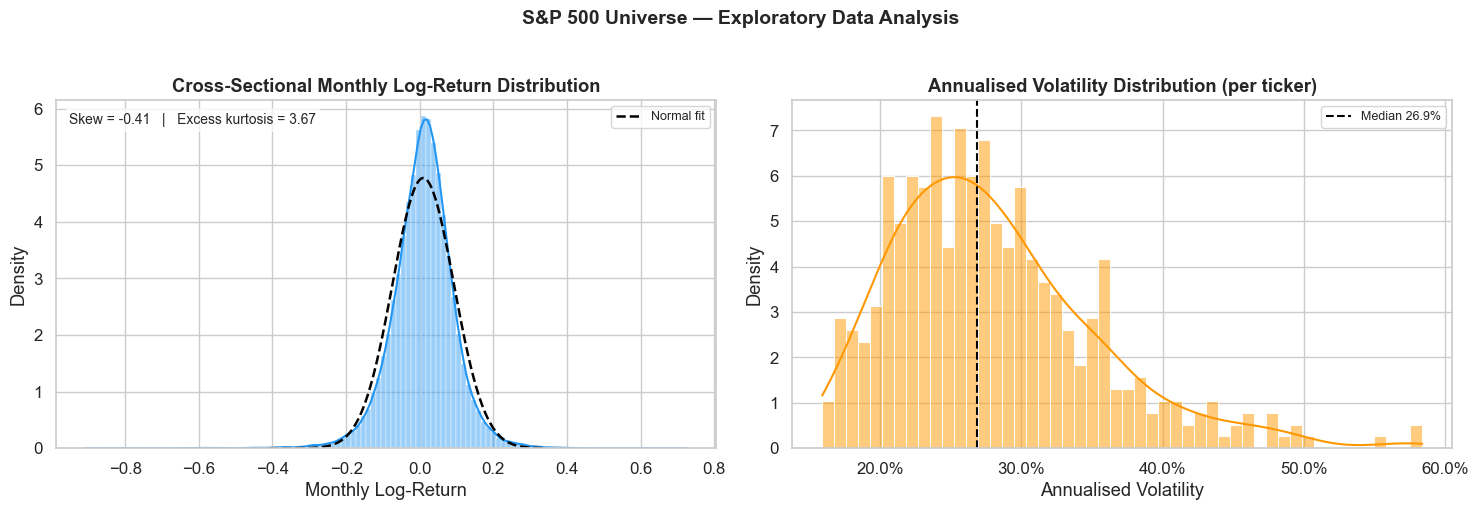

Mean monthly return : 0.0095  (11.45% annualised)
Std monthly return  : 0.0836  (28.95% annualised)
Median ann. vol     : 26.87%


In [13]:
# EDA DASHBOARD
# Two panels: cross-sectional return distribution and annualised volatility.
# Both reveal how the universe behaves before any signal is applied.

all_returns = monthly_ret_wide.stack().dropna()
mu, sigma   = all_returns.mean(), all_returns.std()

ann_vol = (
    monthly_ret_wide
    .std()
    .mul(np.sqrt(12))      # annualise from monthly std: σ_monthly × √12
    .dropna()
    .rename("ann_vol")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Cross-sectional monthly return distribution
# Overlay a fitted normal to show how much the tails deviate from normality
sns.histplot(all_returns, bins=120, kde=True, stat="density",
             color="#2196F3", alpha=0.45, ax=axes[0])

x_range = np.linspace(all_returns.quantile(0.001), all_returns.quantile(0.999), 400)
axes[0].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
             "k--", lw=1.8, label="Normal fit")

axes[0].text(0.02, 0.93,
             f"Skew = {float(all_returns.skew()):.2f}   |   "
             f"Excess kurtosis = {float(all_returns.kurt()):.2f}",
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

axes[0].set_title("Cross-Sectional Monthly Log-Return Distribution",
                  fontweight="bold")
axes[0].set_xlabel("Monthly Log-Return")
axes[0].legend(fontsize=9)

# Panel 2: Annualised volatility distribution
# Per-ticker volatility over the full history — shows the risk spread of the universe
sns.histplot(ann_vol, bins=50, kde=True, stat="density",
             color="#FF9800", alpha=0.5, ax=axes[1])
axes[1].axvline(ann_vol.median(), color="black", lw=1.5, ls="--",
                label=f"Median {ann_vol.median():.1%}")
axes[1].set_title("Annualised Volatility Distribution (per ticker)",
                  fontweight="bold")
axes[1].set_xlabel("Annualised Volatility")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(fontsize=9)

plt.suptitle("S&P 500 Universe — Exploratory Data Analysis",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean monthly return : {mu:.4f}  ({mu*12:.2%} annualised)")
print(f"Std monthly return  : {sigma:.4f}  ({sigma*np.sqrt(12):.2%} annualised)")
print(f"Median ann. vol     : {ann_vol.median():.2%}")

---
## 5. Momentum Signal Definitions

We construct four momentum signals — two price-return based (computed on monthly prices)
and two technical-indicator based (computed on daily prices then sampled monthly).
Each signal is a standalone function that returns a DataFrame of the same shape
as `monthly_ret_wide`: rows = month-end dates, columns = tickers.

### Signal overview

| Signal | Frequency | Definition |
|--------|-----------|------------|
| **MOM_12_1** | Monthly | Log return from month t−12 to t−1 (skip most recent month) |
| **MOM_3_1** | Monthly | Log return from month t−3 to t−1 (skip most recent month) |
| **MA_Cross** | Daily → monthly | EMA₅₀ / EMA₂₀₀ − 1, sampled at month-end |
| **RSI_14** | Daily → monthly | 14-day RSI sampled at month-end |
| **Composite** | Monthly | Equal-weighted z-score average of all four signals |

### Why skip the most recent month in MOM_12_1 and MOM_3_1?

Jegadeesh & Titman (1993) — the foundational momentum paper — showed that the
most recent month's return actually **reverses** in the following month (short-term
mean reversion). By skipping month t to t−1, we isolate the medium-term trend
from this short-term noise. This is standard practice in academic and practitioner
momentum research.

### Why a continuous signal instead of binary crossover for MA_Cross?

A binary signal (EMA₅₀ > EMA₂₀₀ = 1, else 0) discards information — a stock
barely above the crossover and one far above it would get the same score.
The **ratio minus 1** preserves the magnitude: a value of +0.05 means the fast MA
is 5% above the slow MA, while +0.20 means it is much further ahead. This makes
the signal rankable across stocks, which is what the backtesting engine needs.

In [14]:
# Monthly price pivot — wide format indexed by month-end
# Used by compute_mom_12_1 and compute_mom_3_1
monthly_close_wide = (
    monthly_prices
    .pivot(index="month_end", columns="ticker", values="close")
)


# SIGNAL FUNCTIONS

def compute_mom_12_1(monthly_close):
    """
    Classic 12-1 month momentum (Jegadeesh & Titman, 1993).
    Return from month t-12 to t-1, skipping the most recent month.

    Formula: log(P_{t-1} / P_{t-12})
    .shift(1) skips the most recent month; .shift(12) goes back one year.
    """
    return np.log(monthly_close.shift(1) / monthly_close.shift(12))


def compute_mom_3_1(monthly_close):
    """
    Short-term 3-1 month momentum.
    Same skip-one-month convention as MOM_12_1 but over a shorter horizon.

    Formula: log(P_{t-1} / P_{t-3})
    """
    return np.log(monthly_close.shift(1) / monthly_close.shift(3))


def compute_ma_cross(daily_prices_df):
    """
    Moving-average crossover: EMA_50 / EMA_200 - 1, sampled at month-end.

    A positive value means the fast EMA is above the slow EMA — uptrend.
    The magnitude tells us how far apart they are, which is more informative
    than a binary above/below flag.

    Computed on daily prices then resampled to month-end so the EMA
    calculations use the full daily resolution they require.
    """
    def _ma_cross_single(px):
        ema50  = px.ewm(span=50,  adjust=False).mean()
        ema200 = px.ewm(span=200, adjust=False).mean()
        return (ema50 / ema200) - 1

    return (
        daily_prices_df
        .sort_values(["ticker", "date"])
        .set_index("date")
        .groupby("ticker")["close"]
        .apply(_ma_cross_single)
        .rename("ma_cross")
        .reset_index()
        .set_index("date")
        .groupby("ticker")["ma_cross"]
        .resample(REBALANCE_FREQ)
        .last()
        .unstack("ticker")
    )


def compute_rsi(daily_prices_df, period=14):
    """
    Relative Strength Index with a 14-day lookback, sampled at month-end.

    RSI measures the speed and magnitude of recent price moves.
    We use it as a continuous momentum signal: higher RSI = stronger momentum.
    Wilder's smoothing: EMA with span = 2*period - 1.
    """
    def _rsi_single(px):
        delta    = px.diff()
        gain     = delta.clip(lower=0)
        loss     = (-delta).clip(lower=0)
        avg_gain = gain.ewm(span=2 * period - 1, adjust=False).mean()
        avg_loss = loss.ewm(span=2 * period - 1, adjust=False).mean()
        rs       = avg_gain / avg_loss.replace(0, np.nan)
        return 100 - (100 / (1 + rs))

    return (
        daily_prices_df
        .sort_values(["ticker", "date"])
        .set_index("date")
        .groupby("ticker")["close"]
        .apply(_rsi_single)
        .rename("rsi")
        .reset_index()
        .set_index("date")
        .groupby("ticker")["rsi"]
        .resample(REBALANCE_FREQ)
        .last()
        .unstack("ticker")
    )


def z_score_cross_section(signal_df):
    """
    Normalise each signal to zero mean and unit standard deviation
    across the cross-section (all tickers) in each month.

    Makes signals from different scales directly comparable and ensures
    no single signal dominates the Composite due to scale alone.
    """
    return signal_df.apply(lambda row: (row - row.mean()) / row.std(), axis=1)


def compute_composite(signal_dict):
    """
    Equal-weighted average of the z-scored individual signals.

    Each signal is first z-scored cross-sectionally then averaged.
    A stock with a high composite score ranks highly across multiple
    independent signals — a more robust candidate than one ranked
    highly by a single signal alone.
    """
    z_signals = {name: z_score_cross_section(df) for name, df in signal_dict.items()}
    return pd.concat(z_signals.values()).groupby(level=0).mean()


print("Signal functions defined.")

Signal functions defined.


In [15]:
# COMPUTE ALL SIGNALS
# Daily prices loaded fresh from DuckDB for MA_Cross and RSI_14,
# which require full daily resolution before resampling to month-end.

con = duckdb.connect(str(DB_PATH))

daily_clean = (
    con.execute("""
        SELECT date, ticker, close
        FROM   daily_prices
        ORDER  BY ticker, date
    """)
    .df()
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .loc[lambda x: x["ticker"].isin(clean_tickers)]
    .copy()
)

con.close()

print("Computing MOM_12_1 ...")
sig_mom12 = compute_mom_12_1(monthly_close_wide)

print("Computing MOM_3_1 ...")
sig_mom3  = compute_mom_3_1(monthly_close_wide)

print("Computing MA_Cross ...")
sig_ma    = compute_ma_cross(daily_clean)

print("Computing RSI_14 ...")
sig_rsi   = compute_rsi(daily_clean)

# Align all signals to a common index and column set
# The intersection ensures every strategy uses identical dates and tickers
common_idx = (
    sig_mom12.index
    .intersection(sig_mom3.index)
    .intersection(sig_ma.index)
    .intersection(sig_rsi.index)
)

common_cols = list(
    set(sig_mom12.columns)
    .intersection(sig_mom3.columns)
    .intersection(sig_ma.columns)
    .intersection(sig_rsi.columns)
)

sig_mom12 = sig_mom12.loc[common_idx, common_cols]
sig_mom3  = sig_mom3.loc[common_idx,  common_cols]
sig_ma    = sig_ma.loc[common_idx,    common_cols]
sig_rsi   = sig_rsi.loc[common_idx,   common_cols]

signal_dict = {
    "MOM_12_1" : sig_mom12,
    "MOM_3_1"  : sig_mom3,
    "MA_Cross" : sig_ma,
    "RSI_14"   : sig_rsi,
}

print("Computing Composite ...")
sig_composite = compute_composite(signal_dict)

all_signals = {**signal_dict, "Composite": sig_composite}

print(f"\nAll signals computed.")
print(f"Signal shape : {sig_mom12.shape[0]} months × {sig_mom12.shape[1]} tickers")
print(f"Date range   : {common_idx.min().date()}  →  {common_idx.max().date()}")

Computing MOM_12_1 ...
Computing MOM_3_1 ...
Computing MA_Cross ...
Computing RSI_14 ...
Computing Composite ...

All signals computed.
Signal shape : 120 months × 451 tickers
Date range   : 2016-04-30  →  2026-03-31


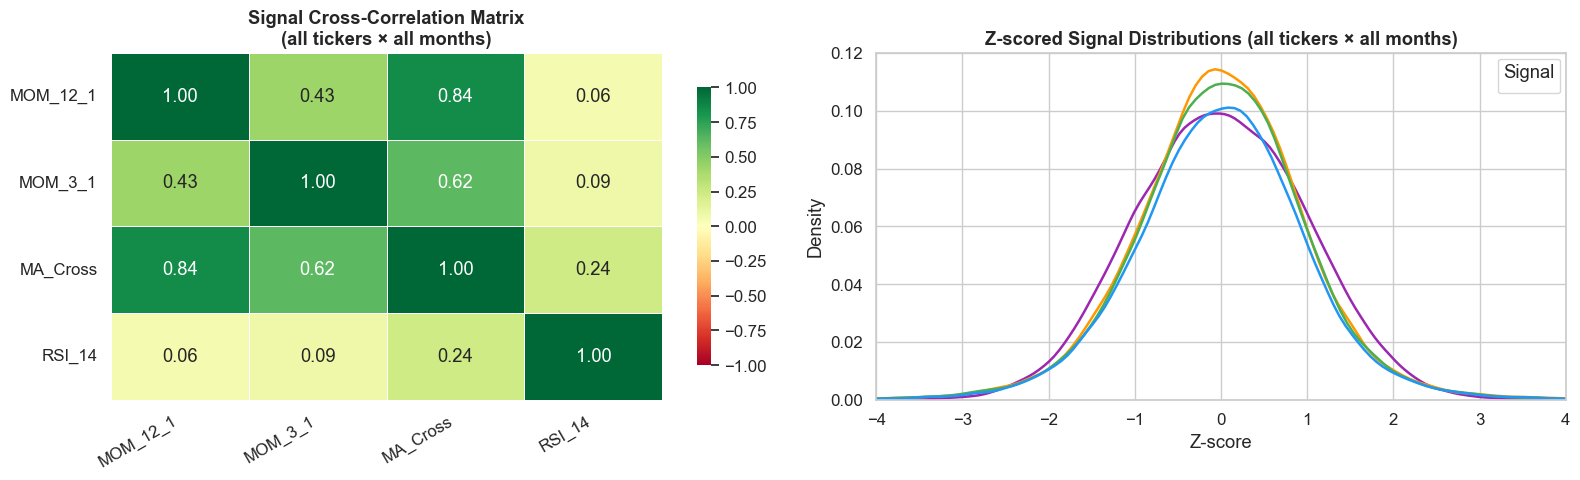

In [17]:
# SIGNAL DIAGNOSTICS
# Two charts: signal cross-correlations and z-scored distributions.
# Low correlations between signals mean the Composite captures genuinely
# independent information rather than repeating the same ranking.

# Stack all signals into long format — one row per (month, ticker) observation
# This is the right shape for both the correlation matrix and the KDE plot
stacked = (
    pd.concat(
        {name: df.stack().rename(name) for name, df in signal_dict.items()},
        axis=1
    )
    .dropna()
)

corr_matrix = stacked.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Correlation heatmap
# Values close to 0 mean the two signals capture independent information —
# good news for the Composite, which benefits from combining independent signals
sns.heatmap(
    corr_matrix, ax=axes[0],
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
axes[0].set_title("Signal Cross-Correlation Matrix\n(all tickers × all months)",
                  fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Panel 2: Z-scored signal distributions
# Melt all four z-scored signals into long format so seaborn can plot
# each signal as a separate hue — no loop needed
z_long = (
    pd.concat(
        {name: z_score_cross_section(df).stack().rename("z")
         for name, df in signal_dict.items()},
        names=["Signal", "month", "ticker"]
    )
    .reset_index(level="Signal")
    .reset_index(drop=True)
    .dropna()
)

sns.kdeplot(
    data=z_long,
    x="z",
    hue="Signal",
    hue_order=SIGNAL_COLS,
    palette={name: COLOURS[name] for name in SIGNAL_COLS},
    lw=1.8,
    ax=axes[1],
)

axes[1].set_xlim(-4, 4)
axes[1].set_title("Z-scored Signal Distributions (all tickers × all months)",
                  fontweight="bold")
axes[1].set_xlabel("Z-score")
axes[1].legend(title="Signal", fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Walk-Forward Backtesting Engine

Each month, stocks are ranked by their signal score. The top 10 % form the
long portfolio and the bottom 10 % form the short portfolio (long-short mode only).
Both portfolios are equal-weighted and held for one month.

Transaction costs are deducted based on turnover — the fraction of the portfolio
that changes relative to the prior month. A turnover of 100 % means the entire
portfolio is replaced; lower turnover means lower costs.

| Mode | Portfolio | Notes |
|------|-----------|-------|
| `long_only` | Top decile only | Lower return and volatility |
| `long_short` | Top decile long + bottom decile short | Higher potential alpha; requires short-selling |

The benchmark is the equal-weighted average return of all clean universe stocks.
If `^GSPC` is present in the database it is used instead.

In [18]:
# BACKTEST ENGINE

def run_backtest(signal_df, returns_wide, mode="long_only",
                 top_q=TOP_DECILE, bot_q=BOTTOM_DECILE,
                 cost_bps=TRANSACTION_COST_BPS):
    """
    Walk-forward backtest for a single signal.

    Parameters
    ----------
    signal_df    : DataFrame [months × tickers] — the ranking signal
    returns_wide : DataFrame [months × tickers] — next-month log-returns
    mode         : 'long_only' or 'long_short'
    top_q        : quantile threshold for the long portfolio
    bot_q        : quantile threshold for the short portfolio
    cost_bps     : transaction cost in basis points, applied to turnover

    Returns
    -------
    Series of monthly portfolio returns indexed by month-end date.
    """
    cost_rate  = cost_bps / 10_000
    months     = signal_df.index.intersection(returns_wide.index)
    port_rets  = []
    prev_long  = set()
    prev_short = set()

    for i, month in enumerate(months[:-1]):    # signal at month t, hold through month t+1
        next_month = months[i + 1]
        scores     = signal_df.loc[month].dropna()

        if len(scores) < 20:                   # need enough stocks to form deciles
            continue

        # Rank and select long portfolio
        long_thresh = scores.quantile(1 - top_q)
        long_stocks = set(scores[scores >= long_thresh].index)

        long_ret = (
            returns_wide
            .loc[next_month, list(long_stocks)]
            .dropna()
            .mean()                            # equal-weighted
        )

        # Transaction cost applied to the fraction of portfolio that changes
        long_turnover = (
            1.0 if not prev_long
            else 1 - len(long_stocks & prev_long) / max(len(long_stocks), 1)
        )
        net_ret = long_ret - cost_rate * long_turnover

        if mode == "long_short":
            short_thresh = scores.quantile(bot_q)
            short_stocks = set(scores[scores <= short_thresh].index)

            short_ret = (
                returns_wide
                .loc[next_month, list(short_stocks)]
                .dropna()
                .mean()
            )

            short_turnover = (
                1.0 if not prev_short
                else 1 - len(short_stocks & prev_short) / max(len(short_stocks), 1)
            )

            # Long-short return: gain from longs minus gain from shorts
            net_ret = (
                (long_ret  - cost_rate * long_turnover) -
                (short_ret - cost_rate * short_turnover)
            )

            prev_short = short_stocks

        prev_long = long_stocks
        port_rets.append({"month": next_month, "return": net_ret})

    return (
        pd.DataFrame(port_rets)
        .set_index("month")["return"]
    )


print("Backtest engine defined.")

Backtest engine defined.


In [20]:
# RUN ALL BACKTESTS
# 5 signals × 2 modes = 10 series, plus the benchmark.
# _LO = long-only portfolio, _LS = long-short portfolio.

import itertools

bt_returns = (
    monthly_ret_wide
    .loc[BACKTEST_START:]
    .copy()
)

# Benchmark — use ^GSPC if available, otherwise equal-weighted universe return
con        = duckdb.connect(str(DB_PATH))
gspc_count = con.execute("""
    SELECT COUNT(*) AS n FROM daily_prices WHERE ticker = '^GSPC'
""").df()["n"].iloc[0]

if gspc_count > 0:
    gspc_daily = con.execute("""
        SELECT date, close FROM daily_prices
        WHERE  ticker = '^GSPC' ORDER BY date
    """).df()
    benchmark = (
        gspc_daily
        .assign(date=lambda x: pd.to_datetime(x["date"]))
        .set_index("date")["close"]
        .resample(REBALANCE_FREQ).last()
        .pipe(lambda s: np.log(s / s.shift(1)))
        .dropna()
        .loc[BACKTEST_START:]
        .rename("Benchmark")
    )
    print("Using ^GSPC as benchmark.")
else:
    benchmark = bt_returns.mean(axis=1).rename("Benchmark")
    print("^GSPC not found — using equal-weighted universe return as benchmark.")

con.close()

# Run all signal × mode combinations
backtest_results = {}

for sig_name, mode in itertools.product(SIGNAL_COLS + ["Composite"],
                                         ["long_only", "long_short"]):
    suffix = "LO" if mode == "long_only" else "LS"
    key    = f"{sig_name}_{suffix}"
    print(f"Running {key} ...")
    backtest_results[key] = run_backtest(
        all_signals[sig_name].loc[BACKTEST_START:],
        bt_returns,
        mode=mode,
    )

# Combine into a single DataFrame aligned on month-end dates
backtest_df = (
    pd.DataFrame(backtest_results)
    .join(benchmark, how="inner")
    .dropna(how="all")
)

print(f"\nBacktests complete.")
print(f"Shape  : {backtest_df.shape[0]} months × {backtest_df.shape[1]} strategies")
print(f"Period : {backtest_df.index.min().date()}  →  {backtest_df.index.max().date()}")

^GSPC not found — using equal-weighted universe return as benchmark.
Running MOM_12_1_LO ...
Running MOM_12_1_LS ...
Running MOM_3_1_LO ...
Running MOM_3_1_LS ...
Running MA_Cross_LO ...
Running MA_Cross_LS ...
Running RSI_14_LO ...
Running RSI_14_LS ...
Running Composite_LO ...
Running Composite_LS ...

Backtests complete.
Shape  : 119 months × 11 strategies
Period : 2016-05-31  →  2026-03-31


---
## 7. Machine Learning Layer

Each month's signal values are used to train a binary classifier — predicting
whether a stock will land in the top return decile next month (label = 1) or not
(label = 0). The four z-scored momentum signals from Section 5 are the only features.

The dataset is split 70/30 on time — first 70 % of months for training, last 30 %
for testing. No future data leaks into the training set.

| Model | Role |
|-------|------|
| **Logistic Regression** | Interpretable baseline |
| **Random Forest** | Handles non-linear signal interactions |
| **LightGBM** | Strongest performer on tabular financial data |

The best model's predicted probabilities replace the raw signal score and feed
directly into the same backtest engine used in Section 6.

In [21]:
# BUILD ML DATASET
# Features: z-scored signals at month t (formation month)
# Label   : 1 if the stock lands in the top decile of next-month returns, else 0

# Z-score all signals cross-sectionally
z_signals = {name: z_score_cross_section(df) for name, df in signal_dict.items()}

# Stack z-scored signals into long format — one row per (month, ticker)
signal_long = (
    pd.concat(
        {name: df.stack().rename(name) for name, df in z_signals.items()},
        axis=1
    )
    .reset_index()
    .rename(columns={"month_end": "month", "level_1": "ticker"})
)
signal_long.columns = ["month", "ticker"] + SIGNAL_COLS

# Forward returns — shift by one month so fwd_ret at month t is the
# return earned by holding from t to t+1
fwd_ret = (
    monthly_ret_wide
    .stack()
    .reset_index()
    .rename(columns={"month_end": "month", 0: "fwd_ret"})
    .assign(month=lambda x: x.groupby("ticker")["month"].shift(-1))
    .dropna(subset=["month"])
)

# Merge signals with forward returns and create the binary label
# Label = 1 if the stock is in the top decile of returns that month, else 0
ml_df = (
    signal_long
    .merge(fwd_ret, on=["month", "ticker"], how="inner")
    .dropna()
    .assign(
        label=lambda x: (
            x.groupby("month")["fwd_ret"]
             .transform(lambda r: (r >= r.quantile(1 - TOP_DECILE)).astype(int))
        )
    )
)

print(f"ML dataset shape : {ml_df.shape}")
print(f"Label balance    : {ml_df['label'].mean():.2%} positive (target ≈ {TOP_DECILE:.0%})")

ML dataset shape : (48629, 8)
Label balance    : 10.17% positive (target ≈ 10%)


In [22]:
# TRAIN / TEST SPLIT — 70 % train, 30 % test (strict temporal ordering)
# Sorting by month ensures no future data leaks into the training set.

ml_df = (
    ml_df
    .sort_values("month")
    .reset_index(drop=True)
)

split_idx = int(len(ml_df) * 0.70)
train_df  = ml_df.iloc[:split_idx]
test_df   = ml_df.iloc[split_idx:]

X_train = train_df[SIGNAL_COLS].values
y_train = train_df["label"].values
X_test  = test_df[SIGNAL_COLS].values
y_test  = test_df["label"].values

# Scale features — required for Logistic Regression; harmless for tree models
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only — no leakage
X_test_s  = scaler.transform(X_test)

print(f"Training period : {ml_df.iloc[0]['month'].date()}  →  {train_df.iloc[-1]['month'].date()}")
print(f"Test period     : {ml_df.iloc[split_idx]['month'].date()}  →  {ml_df.iloc[-1]['month'].date()}")
print(f"Train samples   : {len(train_df):,}  |  Test samples : {len(test_df):,}")

Training period : 2017-04-30  →  2023-07-31
Test period     : 2023-07-31  →  2026-03-31
Train samples   : 34,040  |  Test samples : 14,589


In [23]:
# TRAIN THREE MODELS
# Models are ordered by complexity — Logistic Regression as interpretable
# baseline, Random Forest for non-linear interactions, LightGBM for performance.

# Logistic Regression — L2 regularised, uses scaled features
lr = LogisticRegression(C=1.0, max_iter=500, random_state=42)
lr.fit(X_train_s, y_train)
lr_prob = lr.predict_proba(X_test_s)[:, 1]
lr_pred = lr.predict(X_test_s)

# Random Forest — tree models do not need scaled features
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

# LightGBM — gradient boosting, typically strongest on tabular financial data
lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42,
                           verbose=-1, n_jobs=-1)
lgbm.fit(X_train, y_train)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
lgbm_pred = lgbm.predict(X_test)

# Evaluation metrics
metrics = {
    "Logistic Regression": {
        "AUC-ROC" : roc_auc_score(y_test, lr_prob),
        "F1 Score": f1_score(y_test, lr_pred),
    },
    "Random Forest": {
        "AUC-ROC" : roc_auc_score(y_test, rf_prob),
        "F1 Score": f1_score(y_test, rf_pred),
    },
    "LightGBM": {
        "AUC-ROC" : roc_auc_score(y_test, lgbm_prob),
        "F1 Score": f1_score(y_test, lgbm_pred),
    },
}

display(
    pd.DataFrame(metrics).T
    .style
    .format("{:.4f}")
    .set_caption("Model Evaluation on Test Set — AUC-ROC and F1 Score (higher is better)")
    .background_gradient(cmap="Greens", axis=0)
)

,AUC-ROC,F1 Score
Logistic Regression,0.8821,0.3544
Random Forest,0.8575,0.3792
LightGBM,0.8811,0.3712


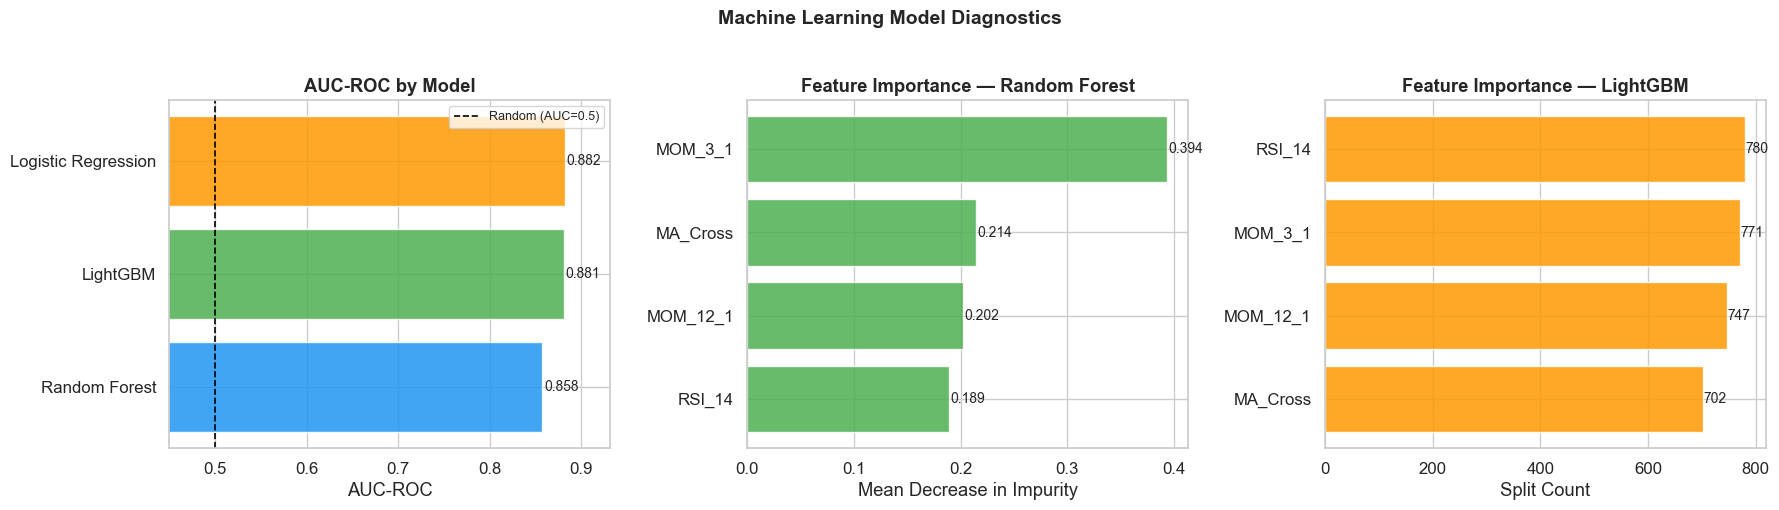

In [24]:
# ML DIAGNOSTICS — AUC comparison and feature importance for RF and LightGBM

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: AUC-ROC comparison across models
auc_df = (
    pd.DataFrame(metrics).T
    .reset_index()
    .rename(columns={"index": "Model"})
    .sort_values("AUC-ROC")
)
model_colours = ["#2196F3", "#4CAF50", "#FF9800"]

axes[0].barh(auc_df["Model"], auc_df["AUC-ROC"], color=model_colours, alpha=0.85)
axes[0].axvline(0.5, color="black", lw=1.2, ls="--", label="Random (AUC=0.5)")
axes[0].set_xlim(0.45, min(1.0, auc_df["AUC-ROC"].max() + 0.05))
axes[0].set_title("AUC-ROC by Model", fontweight="bold")
axes[0].set_xlabel("AUC-ROC")
axes[0].legend(fontsize=9)

# Annotate bars with AUC values
auc_df.apply(
    lambda row: axes[0].text(
        row["AUC-ROC"] + 0.002,
        auc_df["Model"].tolist().index(row["Model"]),
        f"{row['AUC-ROC']:.3f}", va="center", fontsize=10
    ), axis=1
)

# Panel 2: Random Forest feature importance
rf_imp = (
    pd.Series(rf.feature_importances_, index=SIGNAL_COLS)
    .sort_values()
)
axes[1].barh(rf_imp.index, rf_imp.values, color="#4CAF50", alpha=0.85)
axes[1].set_title("Feature Importance — Random Forest", fontweight="bold")
axes[1].set_xlabel("Mean Decrease in Impurity")

rf_imp.reset_index().apply(
    lambda row: axes[1].text(
        row["MOM_12_1"] + 0.001 if "MOM_12_1" in row.index else row.iloc[1] + 0.001,
        rf_imp.index.tolist().index(row.iloc[0]),
        f"{row.iloc[1]:.3f}", va="center", fontsize=10
    ), axis=1
)

# Panel 3: LightGBM feature importance
lgbm_imp = (
    pd.Series(lgbm.feature_importances_, index=SIGNAL_COLS)
    .sort_values()
)
axes[2].barh(lgbm_imp.index, lgbm_imp.values, color="#FF9800", alpha=0.85)
axes[2].set_title("Feature Importance — LightGBM", fontweight="bold")
axes[2].set_xlabel("Split Count")

lgbm_imp.reset_index().apply(
    lambda row: axes[2].text(
        row.iloc[1] + 0.5,
        lgbm_imp.index.tolist().index(row.iloc[0]),
        f"{row.iloc[1]:.0f}", va="center", fontsize=10
    ), axis=1
)

plt.suptitle("Machine Learning Model Diagnostics", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# ML SIGNAL BACKTEST
# The best model's predicted probability replaces the raw signal score.
# Higher probability of being top-decile → higher portfolio ranking.

# Select best model by AUC — dict lookup replaces if/elif/else
prob_map = {
    "Logistic Regression" : lr_prob,
    "Random Forest"       : rf_prob,
    "LightGBM"            : lgbm_prob,
}
best_model_name = max(metrics, key=lambda k: metrics[k]["AUC-ROC"])
best_prob       = prob_map[best_model_name]

print(f"Best model by AUC : {best_model_name}")

# Build wide-format signal DataFrame from predicted probabilities
ml_signal_wide = (
    test_df[["month", "ticker"]]
    .assign(ml_prob=best_prob)
    .pivot(index="month", columns="ticker", values="ml_prob")
)

# Run backtest for both modes using the ML signal
for mode in ["long_only", "long_short"]:
    suffix = "LO" if mode == "long_only" else "LS"
    key    = f"ML_{suffix}"
    print(f"Running {key} ...")
    backtest_results[key] = run_backtest(
        ml_signal_wide,
        bt_returns.loc[bt_returns.index.intersection(ml_signal_wide.index)],
        mode=mode,
    )

# Rebuild backtest_df including ML series
backtest_df = (
    pd.DataFrame(backtest_results)
    .join(benchmark, how="inner")
    .dropna(how="all")
)

print(f"\nML backtest added. Total strategies : {backtest_df.shape[1]}")

Best model by AUC : Logistic Regression
Running ML_LO ...
Running ML_LS ...

ML backtest added. Total strategies : 13


---
## 8. Performance Metrics & Visualisation

Six metrics are computed for every strategy and displayed in a summary table,
followed by a four-panel dashboard.

| Metric | What it measures |
|--------|-----------------|
| **Annualised Return** | Average annual profit |
| **Annualised Volatility** | Year-on-year risk |
| **Sharpe Ratio** | Return per unit of risk |
| **Max Drawdown** | Worst peak-to-trough loss |
| **Calmar Ratio** | Return per unit of drawdown |
| **Win Rate** | Fraction of months with positive return |

The dashboard shows cumulative returns, rolling 12-month Sharpe, drawdown
profiles, and a Sharpe vs Calmar bar chart. Line charts show the best-performing
mode per signal (solid = long-only, dashed = long-short). The bar chart includes
all strategies.

In [26]:
# PERFORMANCE METRICS

def performance_metrics(returns_series, rf=RF_ANNUAL):
    """
    Compute standard performance metrics for a monthly return series.

    Parameters
    ----------
    returns_series : pd.Series of monthly log-returns
    rf             : annual risk-free rate

    Returns
    -------
    dict of metric name → value
    """
    r = returns_series.dropna()

    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe  = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    # Max drawdown — cumulative wealth index; drawdown = (peak - current) / peak
    wealth = (1 + r).cumprod()
    peak   = wealth.cummax()
    max_dd = ((wealth - peak) / peak).min()

    calmar   = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    win_rate = (r > 0).mean()

    return {
        "Ann. Return"  : ann_ret,
        "Ann. Vol"     : ann_vol,
        "Sharpe"       : sharpe,
        "Max Drawdown" : max_dd,
        "Calmar"       : calmar,
        "Win Rate"     : win_rate,
    }


perf_df = (
    pd.DataFrame(
        {col: performance_metrics(backtest_df[col]) for col in backtest_df.columns}
    )
    .T
    .sort_values("Sharpe", ascending=False)
)

display(
    perf_df
    .style
    .format({
        "Ann. Return"  : "{:.2%}",
        "Ann. Vol"     : "{:.2%}",
        "Sharpe"       : "{:.2f}",
        "Max Drawdown" : "{:.2%}",
        "Calmar"       : "{:.2f}",
        "Win Rate"     : "{:.2%}",
    })
    .set_caption("Strategy Performance Summary (sorted by Sharpe Ratio)")
    .background_gradient(subset=["Sharpe", "Calmar"], cmap="RdYlGn")
    .background_gradient(subset=["Max Drawdown"], cmap="RdYlGn_r")
)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Calmar,Win Rate
Composite_LO,14.06%,17.51%,0.57,-21.91%,0.64,66.39%
MA_Cross_LO,14.02%,17.86%,0.56,-24.98%,0.56,64.71%
MOM_3_1_LO,13.58%,18.05%,0.53,-24.42%,0.56,65.52%
MOM_12_1_LO,13.48%,18.88%,0.50,-23.65%,0.57,62.62%
RSI_14_LO,10.73%,14.40%,0.47,-19.97%,0.54,64.71%
Benchmark,11.52%,16.09%,0.47,-26.44%,0.44,67.23%
ML_LO,7.81%,15.75%,0.24,-14.98%,0.52,53.12%
MOM_12_1_LS,3.70%,17.07%,-0.02,-35.15%,0.11,49.53%
MA_Cross_LS,3.68%,17.83%,-0.02,-28.62%,0.13,49.58%
Composite_LS,1.59%,17.43%,-0.14,-28.86%,0.06,52.94%


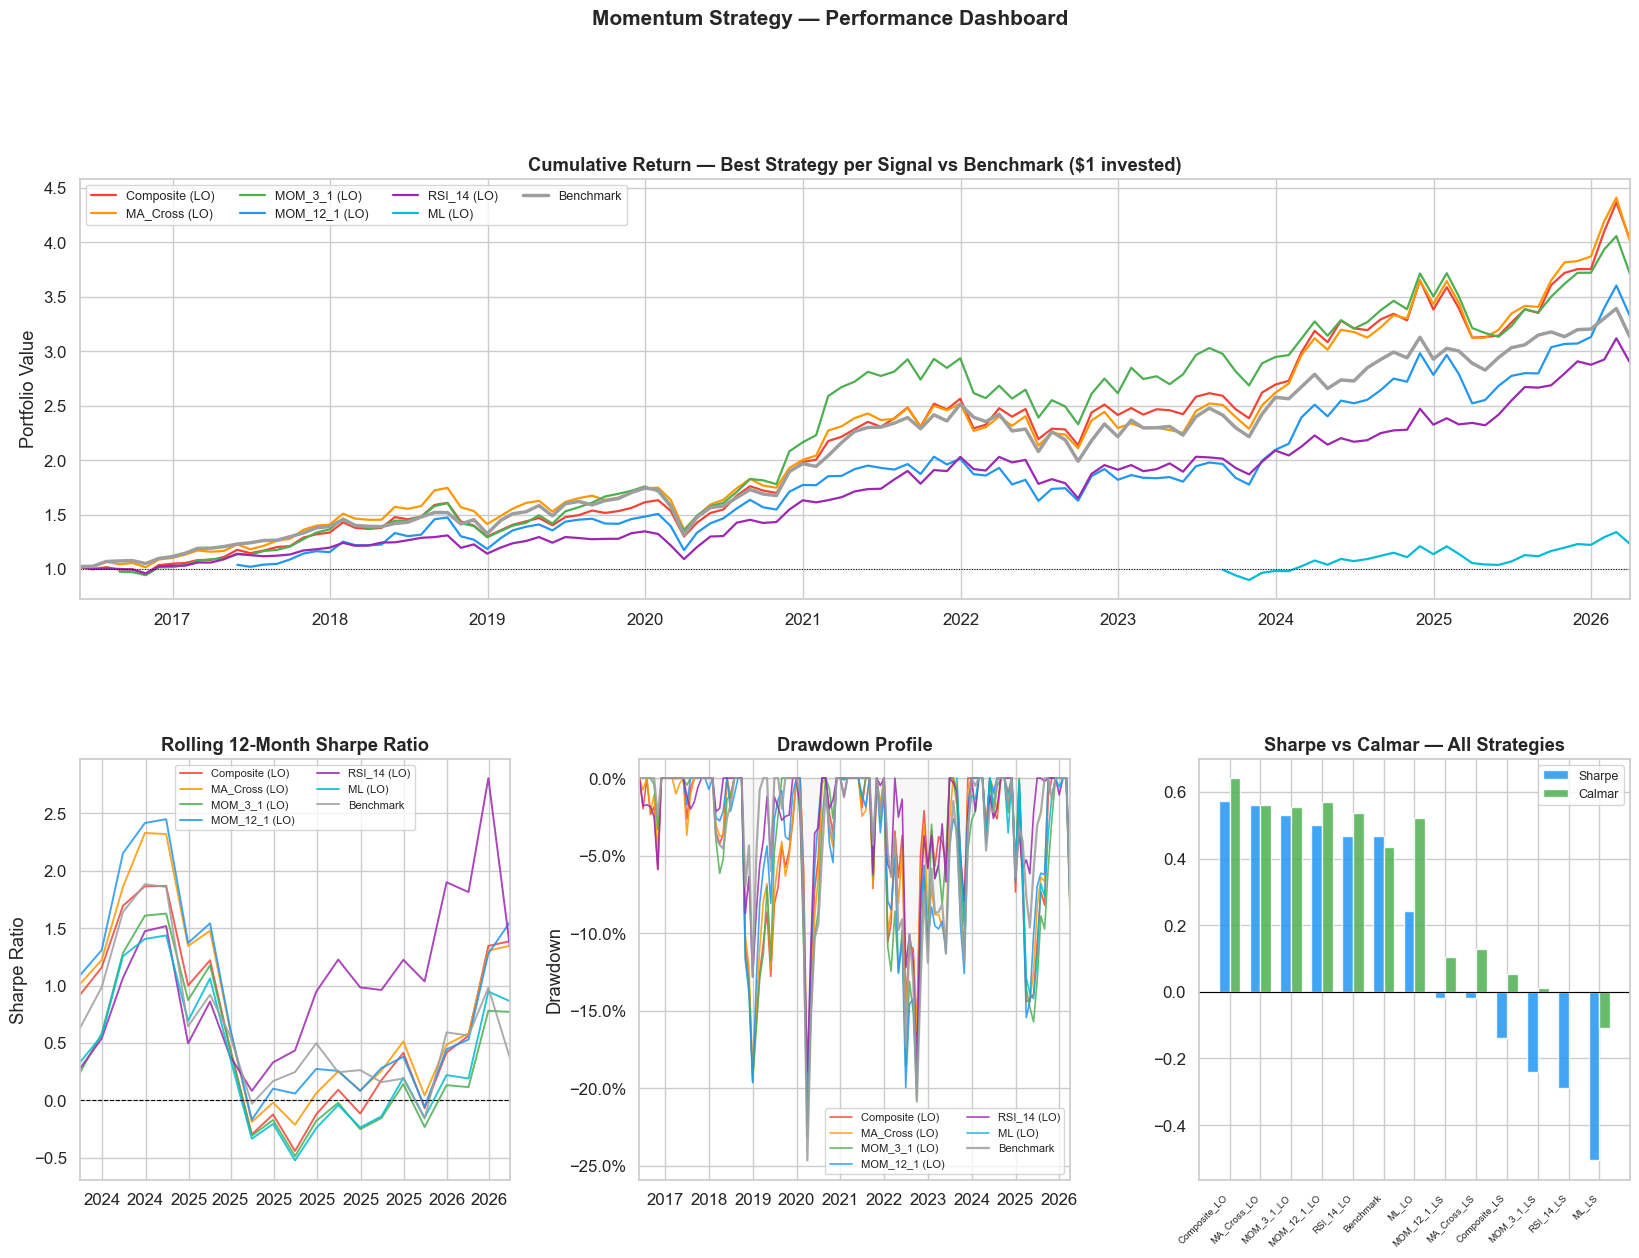

In [28]:
# PERFORMANCE DASHBOARD
# GridSpec layout:
#   Row 0 (full width) : cumulative returns — best mode per signal family
#   Row 1 left         : rolling 12-month Sharpe
#   Row 1 centre       : drawdown profiles
#   Row 1 right        : Sharpe & Calmar bar chart — all strategies

# Select the best mode (LO or LS) per signal family by Sharpe ratio
# Colour = signal family, line style = mode (solid LO, dashed LS)
signal_families = SIGNAL_COLS + ["Composite", "ML"]

best_cols = (
    perf_df
    .reset_index()
    .rename(columns={"index": "col"})
    .assign(family=lambda x: x["col"].str.replace("_LO|_LS", "", regex=True))
    .query("family in @signal_families")
    .sort_values("Sharpe", ascending=False)
    .drop_duplicates(subset="family", keep="first")
    ["col"]
    .tolist()
)

# Subset of backtest_df for line charts — best strategy per family + Benchmark
plot_cols = best_cols + ["Benchmark"]
plot_df   = backtest_df[plot_cols]

def get_colour(col):
    """Consistent colour per signal family from COLOURS dict."""
    return next((c for k, c in COLOURS.items() if k in col), "#607D8B")

def get_ls(col):
    """Dashed for long-short, solid for long-only."""
    return "--" if "_LS" in col else "-"

def get_label(col):
    """Clean legend label showing signal name and mode."""
    if col == "Benchmark":
        return "Benchmark"
    mode = "LS" if "_LS" in col else "LO"
    name = col.replace("_LO", "").replace("_LS", "")
    return f"{name} ({mode})"


fig = plt.figure(figsize=(20, 13))
gs  = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.3)

ax_cum = fig.add_subplot(gs[0, :])
ax_sr  = fig.add_subplot(gs[1, 0])
ax_dd  = fig.add_subplot(gs[1, 1])
ax_bar = fig.add_subplot(gs[1, 2])

# Panel 1: Cumulative returns
# exp(cumsum(log-returns)) gives a wealth index starting at 1.0
cum_ret = plot_df.cumsum().apply(np.exp)

for col in cum_ret.columns:
    ax_cum.plot(
        cum_ret.index, cum_ret[col],
        color=get_colour(col), ls=get_ls(col),
        lw=2.5 if col == "Benchmark" else 1.6,
        label=get_label(col),
    )

ax_cum.axhline(1, color="black", lw=0.7, ls=":")
ax_cum.set_title("Cumulative Return — Best Strategy per Signal vs Benchmark ($1 invested)",
                 fontweight="bold")
ax_cum.set_ylabel("Portfolio Value")
ax_cum.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_cum.legend(ncol=4, fontsize=9, loc="upper left")
ax_cum.margins(x=0)

# Panel 2: Rolling 12-month Sharpe
# Sustained positive values indicate consistent rather than lucky performance
roll_sharpe = (
    plot_df
    .rolling(12)
    .apply(lambda r: (r.mean() * 12 - RF_ANNUAL) / (r.std() * np.sqrt(12)))
    .dropna()
)

for col in roll_sharpe.columns:
    ax_sr.plot(
        roll_sharpe.index, roll_sharpe[col],
        color=get_colour(col), ls=get_ls(col),
        lw=1.4, label=get_label(col), alpha=0.85,
    )

ax_sr.axhline(0, color="black", lw=0.8, ls="--")
ax_sr.set_title("Rolling 12-Month Sharpe Ratio", fontweight="bold")
ax_sr.set_ylabel("Sharpe Ratio")
ax_sr.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_sr.legend(fontsize=8, ncol=2)
ax_sr.margins(x=0)

# Panel 3: Drawdown profiles
# Line only — no fill, avoids overlapping areas obscuring each other
for col in cum_ret.columns:
    w  = cum_ret[col]
    dd = (w - w.cummax()) / w.cummax()
    ax_dd.plot(
        dd.index, dd.values,
        color=get_colour(col), ls=get_ls(col),
        lw=1.6 if col == "Benchmark" else 1.2,
        label=get_label(col),
        alpha=0.85,
    )

ax_dd.fill_between(
    dd.index, dd.values, 0,   # shade only the benchmark drawdown for context
    alpha=0.08, color="#9E9E9E"
)
ax_dd.set_title("Drawdown Profile", fontweight="bold")
ax_dd.set_ylabel("Drawdown")
ax_dd.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_dd.legend(fontsize=8, ncol=2)
ax_dd.margins(x=0)

# Panel 4: Sharpe and Calmar bar chart — all strategies
# Bar chart handles more series cleanly; each bar is clearly separated
bar_df = perf_df[["Sharpe", "Calmar"]].dropna()
x      = np.arange(len(bar_df))
width  = 0.35

ax_bar.bar(x - width / 2, bar_df["Sharpe"], width,
           label="Sharpe", color="#2196F3", alpha=0.85)
ax_bar.bar(x + width / 2, bar_df["Calmar"], width,
           label="Calmar", color="#4CAF50", alpha=0.85)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bar_df.index, rotation=45, ha="right", fontsize=7)
ax_bar.axhline(0, color="black", lw=0.8)
ax_bar.set_title("Sharpe vs Calmar — All Strategies", fontweight="bold")
ax_bar.legend(fontsize=9)

plt.suptitle("Momentum Strategy — Performance Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Fama-French 3-Factor Risk Adjustment

### Why risk-adjust?

A momentum strategy naturally buys recent winners. Recent winners tend to be
large-cap growth stocks — which means part of our return may simply be compensation
for tilting toward those kinds of stocks, not genuine momentum alpha.

The Fama-French 3-factor model decomposes our portfolio's excess return into:

$$R_{p,t} - R_{f,t} = \alpha + \beta_1 \cdot \text{MktRF}_t + \beta_2 \cdot \text{SMB}_t + \beta_3 \cdot \text{HML}_t + \varepsilon_t$$

| Term | Meaning in plain English |
|------|--------------------------|
| $\alpha$ | Return the strategy earns **after** accounting for market, size, and value tilts — pure momentum skill |
| $\beta_1$ (Market) | How much the strategy simply follows the broad market |
| $\beta_2$ (SMB) | Tilt toward small caps (+) or large caps (−) |
| $\beta_3$ (HML) | Tilt toward value stocks (+) or growth stocks (−) |

A statistically significant positive $\alpha$ (t-stat > 2) means the strategy
generates returns that cannot be explained by standard risk factors — genuine alpha.

In [29]:
# DOWNLOAD FAMA-FRENCH 3-FACTOR DATA
# Monthly factor returns from Kenneth French's website — Mkt-RF, SMB, HML, RF.

FF_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_Factors_CSV.zip"
)

ff_df = None    # initialise — regression cell checks this before running

print("Downloading Fama-French 3-factor data ...")

try:
    resp = requests.get(FF_URL, timeout=30)
    resp.raise_for_status()

    # Unzip and decode
    zf       = zipfile.ZipFile(io.BytesIO(resp.content))
    raw_text = zf.read(zf.namelist()[0]).decode("utf-8", errors="replace")

    # Parse monthly rows only — valid rows have exactly 5 fields and a 6-digit date
    # Annual rows are 4-digit years; header/footer lines fail both checks cleanly
    data_lines = [
        [p.strip() for p in line.split(",")]
        for line in raw_text.splitlines()
        if len(line.split(",")) == 5
        and line.split(",")[0].strip().isdigit()
        and len(line.split(",")[0].strip()) == 6
    ]

    if not data_lines:
        raise ValueError("No monthly rows found — CSV format may have changed.")

    ff_df = (
        pd.DataFrame(data_lines, columns=["yyyymm", "Mkt_RF", "SMB", "HML", "RF"])
        .assign(
            date   = lambda x: pd.to_datetime(x["yyyymm"].str.strip(), format="%Y%m")
                                + pd.offsets.MonthEnd(0),
            Mkt_RF = lambda x: pd.to_numeric(x["Mkt_RF"], errors="coerce") / 100,
            SMB    = lambda x: pd.to_numeric(x["SMB"],    errors="coerce") / 100,
            HML    = lambda x: pd.to_numeric(x["HML"],    errors="coerce") / 100,
            RF     = lambda x: pd.to_numeric(x["RF"],     errors="coerce") / 100,
        )
        .dropna(subset=["Mkt_RF"])
        .set_index("date")
        [["Mkt_RF", "SMB", "HML", "RF"]]
        .loc[lambda x: x.index >= pd.Timestamp(BACKTEST_START)]
    )

    if ff_df.empty:
        raise ValueError(f"No FF data found on or after {BACKTEST_START}.")

    print(f"Fama-French data loaded : {len(ff_df)} months  "
          f"({ff_df.index.min().date()}  →  {ff_df.index.max().date()})")
    display(ff_df.tail(3).style.format("{:.4f}").set_caption("Latest 3 rows"))

except requests.exceptions.ConnectionError:
    print("No internet connection — Section 9 will be skipped.")

except requests.exceptions.Timeout:
    print("Request timed out — try again or check your connection.")

except Exception as e:
    print(f"FF download failed : {type(e).__name__}: {e}")
    print("Section 9 will be skipped.")

Fama-French data loaded : 133 months  (2015-01-31  →  2026-01-31)


,Mkt_RF,SMB,HML,RF
date,,,,
2025-11-30 00:00:00,-0.0013,0.0038,0.0376,0.0030
2025-12-31 00:00:00,-0.0036,-0.0106,0.0242,0.0034
2026-01-31 00:00:00,0.0102,0.0221,0.0370,0.0030


In [30]:
# OLS REGRESSION — NUMPY IMPLEMENTATION
# Avoids adding statsmodels as a dependency.

def ols_regression(y, X):
    """
    OLS regression: y = X @ beta + eps
    X must include the intercept column (column of ones).

    Returns dict with keys: beta, se, t_stat, p_value, r_squared
    """
    n, k  = X.shape
    beta  = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    s2    = (resid @ resid) / (n - k)             # residual variance
    se    = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))

    t_stat = beta / se
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n - k))
    r2      = 1 - (resid @ resid) / ((y - y.mean()) ** 2).sum()

    return {"beta": beta, "se": se, "t_stat": t_stat,
            "p_value": p_value, "r_squared": r2}


# FAMA-FRENCH REGRESSION
# For each strategy: excess return ~ intercept + Mkt-RF + SMB + HML
# Alpha = return unexplained by the three factors. Significant if |t-stat| > 2.

if ff_df is None:
    print("FF data not available — skipping regression.")

else:
    strategy_cols = [c for c in backtest_df.columns if c != "Benchmark"]

    # Standardise both indexes to month-end Timestamps before joining
    bt_clean = backtest_df.copy()
    bt_clean.index = pd.to_datetime(bt_clean.index) + pd.offsets.MonthEnd(0)
    ff_df.index    = pd.to_datetime(ff_df.index)    + pd.offsets.MonthEnd(0)

    results = []

    for col in strategy_cols:
        merged = (
            bt_clean[[col]]
            .rename(columns={col: "ret"})
            .join(ff_df, how="inner")
            .dropna()
        )

        if len(merged) < 12:
            continue

        y = (merged["ret"] - merged["RF"]).values
        X = np.column_stack([
            np.ones(len(merged)),
            merged["Mkt_RF"].values,
            merged["SMB"].values,
            merged["HML"].values,
        ])

        res = ols_regression(y, X)

        results.append({
            "Strategy"      : col,
            "Ann. Alpha"    : res["beta"][0] * 12,
            "Alpha t-stat"  : res["t_stat"][0],
            "Significant?"  : "Yes" if abs(res["t_stat"][0]) > 2 else "No",
            "Market β"      : res["beta"][1],
            "Size β (SMB)"  : res["beta"][2],
            "Value β (HML)" : res["beta"][3],
            "R²"            : res["r_squared"],
        })

    if not results:
        print("No results — check that backtest_df and ff_df have overlapping dates.")
    else:
        display(
            pd.DataFrame(results)
            .set_index("Strategy")
            .style
            .format({
                "Ann. Alpha"    : "{:.2%}",
                "Alpha t-stat"  : "{:.2f}",
                "Market β"      : "{:.2f}",
                "Size β (SMB)"  : "{:.2f}",
                "Value β (HML)" : "{:.2f}",
                "R²"            : "{:.2f}",
            })
            .set_caption(
                "Fama-French 3-Factor Regression  |  "
                "Ann. Alpha = annual return unexplained by market, size, and value factors.  "
                "Significant if |Alpha t-stat| > 2.0"
            )
            .background_gradient(subset=["Ann. Alpha"], cmap="RdYlGn")
            .background_gradient(subset=["R²"], cmap="Blues")
        )

,Ann. Alpha,Alpha t-stat,Significant?,Market β,Size β (SMB),Value β (HML),R²
Strategy,,,,,,,
MOM_12_1_LO,-0.63%,-0.21,No,0.99,0.10,0.05,0.79
MOM_12_1_LS,2.34%,0.43,No,-0.21,-0.16,-0.43,0.19
MOM_3_1_LO,0.19%,0.06,No,0.96,0.14,0.10,0.77
MOM_3_1_LS,0.55%,0.11,No,-0.16,0.00,-0.20,0.06
MA_Cross_LO,0.24%,0.08,No,0.95,0.07,0.08,0.73
MA_Cross_LS,3.77%,0.68,No,-0.25,-0.20,-0.33,0.15
RSI_14_LO,-1.45%,-0.58,No,0.78,-0.08,0.14,0.73
RSI_14_LS,-0.19%,-0.05,No,-0.25,-0.18,-0.14,0.16
Composite_LO,0.19%,0.06,No,0.93,0.02,0.07,0.71


---
## 10. Current Stock Screener

This section produces a real-time ranked view of the clean universe based on the
most recent complete month of data.

Each stock receives a **composite momentum score** — the equal-weighted average
of z-scored individual signal values. A score above zero means the stock ranks
above the median on momentum; a high positive score means multiple signals agree
it is a strong momentum candidate.

### Output

- **Top 10** — highest composite scores: long candidates
- **Bottom 10** — lowest composite scores: short candidates
- Horizontal bar chart: green for top 10, red for bottom 10

In [31]:
# CURRENT STOCK SCREENER
# Ranks all clean universe stocks by composite momentum score
# as of the most recent complete month.

latest_month = sig_composite.index.max()

screener = (
    pd.DataFrame({
        "MOM_12_1" : z_score_cross_section(sig_mom12).loc[latest_month],
        "MOM_3_1"  : z_score_cross_section(sig_mom3).loc[latest_month],
        "MA_Cross" : z_score_cross_section(sig_ma).loc[latest_month],
        "RSI_14"   : z_score_cross_section(sig_rsi).loc[latest_month],
    })
    .assign(Composite=sig_composite.loc[latest_month])
    .dropna()
    .sort_values("Composite", ascending=False)
    .rename_axis("Ticker")
    .reset_index()
)

top10    = screener.head(10)
bottom10 = screener.tail(10).sort_values("Composite")

print(f"Screener date    : {latest_month.date()}")
print(f"Universe size    : {len(screener)} tickers")

display(
    top10
    .style
    .format({c: "{:.2f}" for c in SIGNAL_COLS + ["Composite"]})
    .background_gradient(subset=["Composite"], cmap="Greens")
    .set_caption("Top 10 Momentum Stocks — Long Candidates")
    .hide(axis="index")
)

display(
    bottom10
    .style
    .format({c: "{:.2f}" for c in SIGNAL_COLS + ["Composite"]})
    .background_gradient(subset=["Composite"], cmap="Reds_r")
    .set_caption("Bottom 10 Momentum Stocks — Short Candidates")
    .hide(axis="index")
)

Screener date    : 2026-03-31
Universe size    : 451 tickers


Ticker,MOM_12_1,MOM_3_1,MA_Cross,RSI_14,Composite
WDC,5.17,2.71,4.52,1.69,3.52
CIEN,4.63,2.17,4.37,2.50,3.42
MU,4.07,1.97,4.18,1.38,2.90
STX,4.13,2.13,3.33,1.57,2.79
TER,3.48,2.83,3.65,0.91,2.72
FIX,3.87,2.34,3.00,1.12,2.58
GLW,3.03,3.08,3.02,0.62,2.44
LRCX,2.95,1.62,2.72,1.44,2.18
AMAT,2.30,2.00,2.37,1.61,2.07
TPL,0.05,3.46,1.71,2.31,1.88


Ticker,MOM_12_1,MOM_3_1,MA_Cross,RSI_14,Composite
IT,-3.32,-3.37,-3.18,0.60,-2.32
CSGP,-2.14,-2.97,-2.46,-0.60,-2.04
WDAY,-2.09,-3.37,-2.42,0.15,-1.93
GDDY,-2.58,-2.61,-2.60,0.39,-1.85
FDS,-2.58,-2.18,-2.55,0.47,-1.71
NOW,-1.60,-2.58,-2.33,0.49,-1.51
ADBE,-1.57,-2.19,-1.85,-0.31,-1.48
INTU,-1.63,-3.42,-2.09,1.39,-1.43
HUM,-1.39,-2.24,-1.95,-0.14,-1.43
MOH,-2.68,-1.12,-2.05,0.21,-1.41


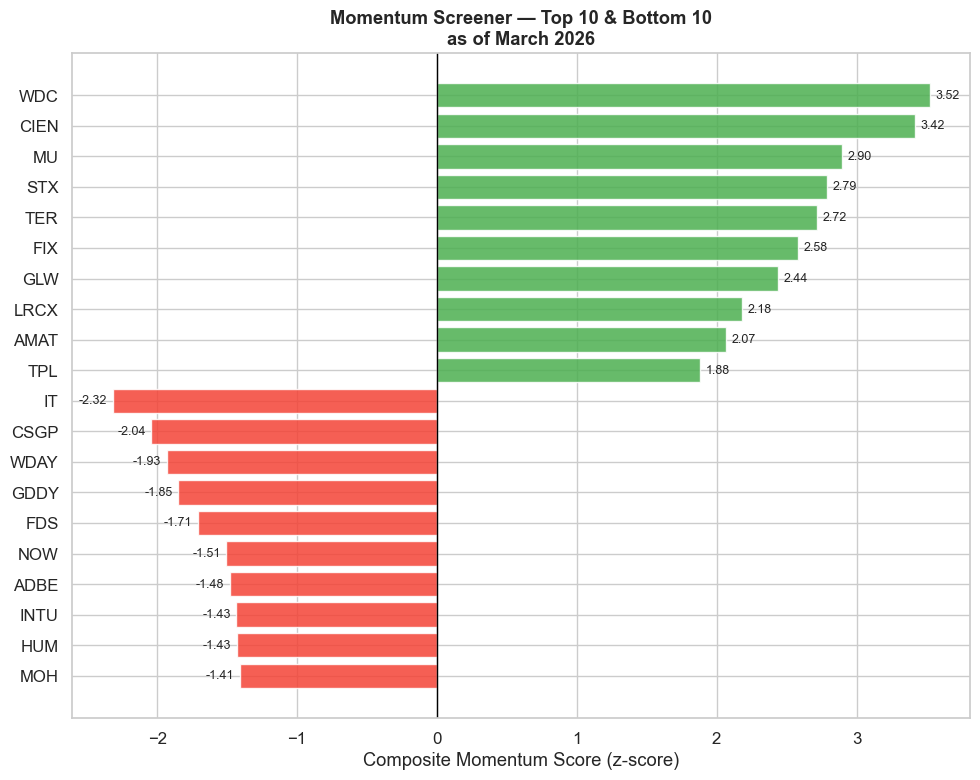

In [32]:
# SCREENER CHART — HORIZONTAL BAR
# Green bars for long candidates (positive score), red for short candidates.

plot_df = (
    pd.concat([top10, bottom10])
    .set_index("Ticker")["Composite"]
)

colours = ["#4CAF50" if v >= 0 else "#F44336" for v in plot_df.values]

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(plot_df.index, plot_df.values, color=colours, alpha=0.85)
ax.axvline(0, color="black", lw=1.0)

# Annotate bars with composite score values
ax.bar_label(
    bars,
    labels=[f"{v:.2f}" for v in plot_df.values],
    padding=4,
    fontsize=9,
)

ax.set_xlabel("Composite Momentum Score (z-score)")
ax.set_title(
    f"Momentum Screener — Top 10 & Bottom 10\n"
    f"as of {latest_month.strftime('%B %Y')}",
    fontweight="bold",
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()